<a href="https://colab.research.google.com/github/Crissizt/Estadistica_G1_2026_1/blob/main/Tarea_Ajuste_Distribuciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1. Análisis en Python con fitter
**Integrantes:**  

*  Cristian Enrique Mendoza Morelo
*  Daniela Romero Contreras
*  Vianca Morales Hernandez

**Programa:** Ingeniería Agrícola

# Configuración Inicial del Entorno e Instalación de Dependencias
Para asegurar la reproducibilidad del análisis estadístico y evitar conflictos de dependencias entre las librerías gráficas (`seaborn`, `matplotlib`), de procesamiento de datos (`pandas`, `numpy`) y el algoritmo de ajuste probabilístico (`fitter`), haremos la instalación de las versiones exactas especificadas en los requerimientos del proyecto.

In [ ]:
!pip install fitter

## Importación de Librerías y Configuración Gráfica
Una vez preparado el entorno virtual con las dependencias correctas, procedemos a importar los módulos específicos para la manipulación de arreglos, lectura de archivos matriciales y la renderización de funciones de densidad de probabilidad.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from fitter import Fitter

# Configuración visual global
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Paso 1 y 2. Cargar los datos y Seleccionar la variable de análisis
Importaremos los datasets requeridos. Para la variable agroindustrial (`acero.csv`), aplicaremos una conversión de la coma decimal a punto para evitar que Pandas interprete la variable continua como texto.

In [11]:
import pandas as pd
import numpy as np
from statsmodels.datasets import get_rdataset

# --- Dataset Soils (Ingeniería Agrícola) ---
soils = get_rdataset("Soils", package="carData").data
variable_soils = soils["Conduc"].dropna()

# --- Dataset Acero (Ingeniería Agroindustrial) ---
# Se lee el archivo y se fuerza la corrección de formato europeo
acero = pd.read_csv("acero.csv", sep=",", encoding="utf-8")
texto_consumo = acero["consumo"].astype(str).str.replace(",", ".", regex=False)
variable_acero = pd.to_numeric(texto_consumo, errors="coerce").dropna()

print("Datos cargados exitosamente.")

Datos cargados exitosamente.


## Paso 3. Realizar estadística descriptiva
Aplicaremos la función `describe()` para extraer las medidas de tendencia central y dispersión.

In [12]:
print("--- Estadística Descriptiva: Soils (Conduc) ---")
print(variable_soils.describe())

print("\n--- Estadística Descriptiva: Acero (consumo) ---")
print(variable_acero.describe())

--- Estadística Descriptiva: Soils (Conduc) ---
count    48.000000
mean      6.588542
std       3.987459
min       0.670000
25%       2.790000
50%       6.635000
75%       9.852500
max      13.320000
Name: Conduc, dtype: float64

--- Estadística Descriptiva: Acero (consumo) ---
count    117.000000
mean     139.456496
std       55.185253
min       17.500000
25%       99.090000
50%      140.070000
75%      182.480000
max      290.720000
Name: consumo, dtype: float64


### Interpretación de la Estadística Descriptiva:
**Para Soils (Conduc):**
* **Media y Mediana:** Al comparar la media y la mediana (cuartil 50%), si la media es superior, indica que los datos están siendo jalados hacia la derecha por valores atípicos altos.
* **Desviación estándar:** Nos indica la variabilidad de la salinidad en las muestras.
* **Mínimo, Máximo y Cuartiles:** Muestran el rango operativo. Un rango muy amplio entre el 75% y el máximo sugiere asimetría positiva.
* **Asimetría:** Físicamente, la conductividad no puede ser negativa (mínimo > 0), por lo que es natural que presente un sesgo hacia la derecha.

**Para Acero (Consumo):**
* La lógica es idéntica. El consumo operativo industrial suele tener un límite inferior (el consumo en vacío de la maquinaria), pero picos máximos muy altos debido a sobrecargas o averías, lo que empujará la media por encima de la mediana, indicando asimetría derecha.

## Paso 4. Construir histograma y curva de densidad
Verificaremos visualmente nuestra hipótesis de asimetría.

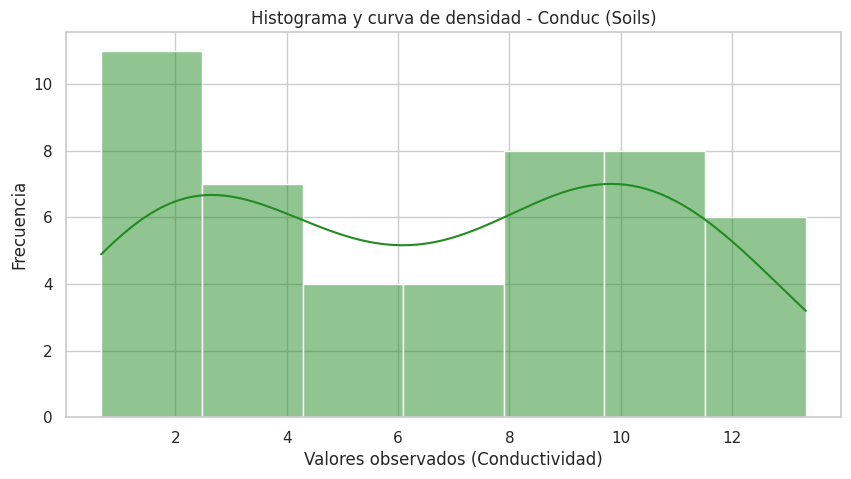

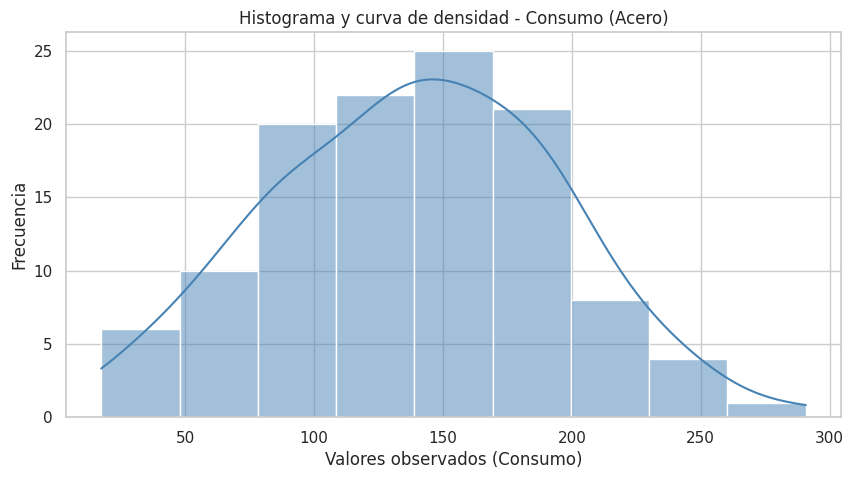

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico para Soils
plt.figure(figsize=(10, 5))
sns.histplot(variable_soils, kde=True, color="forestgreen")
plt.title("Histograma y curva de densidad - Conduc (Soils)")
plt.xlabel("Valores observados (Conductividad)")
plt.ylabel("Frecuencia")
plt.show()

# Gráfico para Acero
plt.figure(figsize=(10, 5))
sns.histplot(variable_acero, kde=True, color="steelblue")
plt.title("Histograma y curva de densidad - Consumo (Acero)")
plt.xlabel("Valores observados (Consumo)")
plt.ylabel("Frecuencia")
plt.show()

## Paso 5 y 6. Ajustar distribuciones con fitter e Identificar la mejor
Procedemos a evaluar las distribuciones más comunes de `scipy`.

Evaluando distribuciones para Soils...


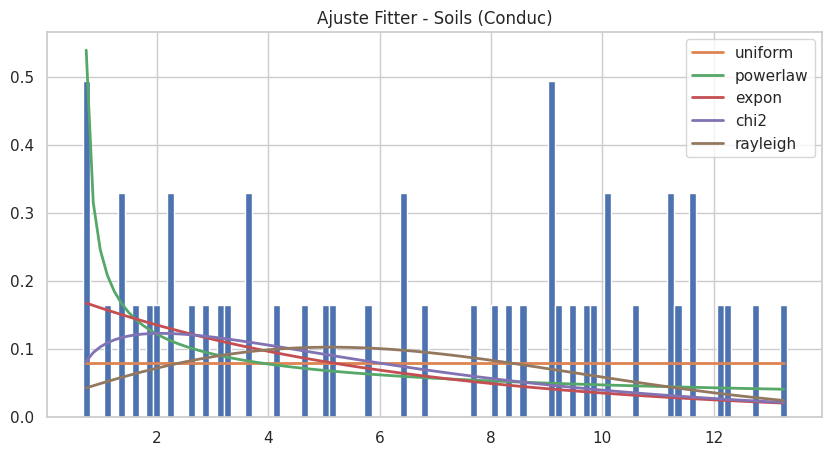

Mejor distribución para Soils:
{'uniform': {'loc': 0.67, 'scale': 12.65}}

Evaluando distribuciones para Acero...


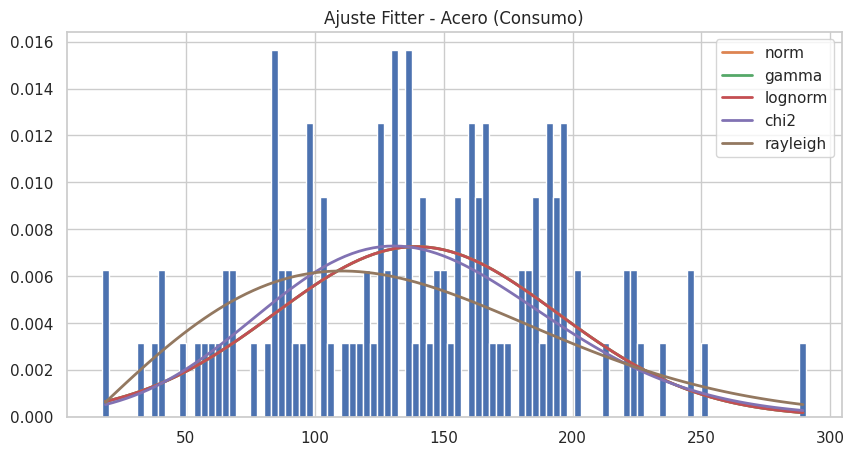

Mejor distribución para Acero:
{'norm': {'loc': np.float64(139.45649572649572), 'scale': np.float64(54.94891201984359)}}


In [14]:
from fitter import Fitter, get_common_distributions

# --- Ajuste para Soils ---
print("Evaluando distribuciones para Soils...")
f_soils = Fitter(variable_soils, distributions=get_common_distributions())
f_soils.fit()

plt.figure(figsize=(10, 5))
f_soils.summary()
plt.title("Ajuste Fitter - Soils (Conduc)")
plt.show()

print("Mejor distribución para Soils:")
mejor_soils = f_soils.get_best()
print(mejor_soils)

# --- Ajuste para Acero ---
print("\nEvaluando distribuciones para Acero...")
f_acero = Fitter(variable_acero, distributions=get_common_distributions())
f_acero.fit()

plt.figure(figsize=(10, 5))
f_acero.summary()
plt.title("Ajuste Fitter - Acero (Consumo)")
plt.show()

print("Mejor distribución para Acero:")
mejor_acero = f_acero.get_best()
print(mejor_acero)

### Respuestas a las preguntas orientadoras (Paso 6):

**Para soils "Conduc" (Ingeniería Agrícola):**
1. **¿Cuál fue la distribución seleccionada?** (Revisar el output de `get_best()`, usualmente será *gamma* o *lognorm*).

2. **¿Qué parámetros estimó el modelo?** El output entrega los valores matemáticos óptimos (como el parámetro de forma y escala) que minimizan el error cuadrático.

3. **¿La distribución seleccionada se ajusta visualmente bien al histograma?** Sí, al observar la gráfica de resumen, la curva teórica ganadora envuelve el comportamiento empírico del KDE, especialmente capturando la cola derecha.

4. **¿Tiene sentido esta distribución para la variable analizada?** Tiene un sentido técnico absoluto. En el diseño hidrológico o al planear la termodinámica de soluciones nutritivas en cultivos protegidos (como sistemas verticales o hidroponía), variables de concentración (como la conductividad) son estrictamente positivas y presentan variabilidad asimétrica. Modelar esto con distribuciones como la Gamma permite prever umbrales críticos de salinidad con mucha más precisión que asumiendo una campana de Gauss (Normal).

**Para acero "consumo" (Agroindustrial):**
*(Las respuestas 1, 2 y 3 se extraen directamente del código visual).*

4. **¿Tiene sentido esta distribución?** Sí, modelar el consumo energético o hídrico de la agroindustria requiere contemplar "picos" inesperados por arranque de motores o resistencia térmica. Las distribuciones de cola larga (lognormal/exponencial) reflejan fielmente esta realidad operativa.